# Test out source code

In [45]:
using Pkg 
Pkg.activate("../.")
include("../src/model.jl")
include("../parameters/no_RA_intermidiate.jl")

  Activating project at `~/github/FisheriesInsuranceModel`


ComponentVector{Float64}(b0 = 1.0, g = 0.850441204540233, m̄ = 0.2, m̲ = 0.8931471805599454, r0 = 0.05505466645826072, z = 0.75, b_target = 0.4, b_limit = 0.2, f_target = 0.15870058672439358, T = [0.975 0.5; 0.025 0.5], σ_R = 0.75, μZ = 0.0, μ_P = 18.74677294892589, μ_Ce = 0.0, s̄ = -2.0, k = 0.02, y0 = -0.3, cf = 1.0e-6, cv = 0.01, κ_bankrupt = 0.01, γ = 0.0)

## Set up random variables

In [46]:
X, Xmc = init_ranom_variables(p;Nquad = 5)

(ValueFunctionIterations.RandomVariableFunction(var"#Xf#1060"{RandomVariable}(RandomVariable([0.0 0.0 … 0.0 0.0; 18.74677294892589 18.74677294892589 … 18.74677294892589 18.74677294892589; … ; -1.515137152842064 -0.7189293484603647 … 0.7189293484603647 1.515137152842064; 0.5 0.5 … 1.0 1.0], [0.030626796875687697, 0.1243038695222464, 0.18856180831641287, 0.1243038695222464, 0.030626796875687697, 0.02909545703190331, 0.11808867604613407, 0.1791337179005922, 0.11808867604613407, 0.02909545703190331, 0.0015313398437843862, 0.006215193476112326, 0.009428090415820652, 0.006215193476112326, 0.0015313398437843862]))), MCRandomVariable(3, 4, [0.045896069876835185 -0.03723338758249917 -0.029939881574184094; 18.71224007201392 18.727365007332526 18.735892087059064; … ; 0.3709123480368529 0.10863352106641595 0.47686282547567377; 0.5 0.975 1.0], [0.5, 0.475, 0.025000000000000022], var"#sampler#1061"{ComponentVector{Float64, Vector{Float64}, Tuple{Axis{(b0 = 1, g = 2, m̄ = 3, m̲ = 4, r0 = 5, z = 6, b_

## Check simulation

[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80]
Precompiling FileIOExt
  ✓ Ghostscript_jll
  ✓ Latexify
  ✓ Qt6ShaderTools_jll
  ✓ Latexify → SparseArraysExt
  ✓ Pango_jll
  ✓ Qt6Declarative_jll
  ✓ UnitfulLatexify
  ✓ Plots → UnitfulExt
  ✓ Plots → FileIOExt
  9 dependencies successfully precompiled in 149 seconds. 155 already precompiled.
[ Info: Precompiling FileIOExt [f5f51d8f-5827-5d2e-939b-192fcd6ec70c]
┌ Warning: Module Plots with build ID fafbfcfd-38c6-7bab-0003-8baef3df301d is missing from the cache.
│ This may mean Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1948
[ Info: Skipping precompilation since __precompile__(false). Importing FileIOExt [f5f51d8f-5827-5d2e-939b-192fcd6ec70c].
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a]
┌ Warning: Module Plots with build ID fafbfcfd-38c6-7bab-0003-8baef3df301d is missing from the cache.
│ This may mean P

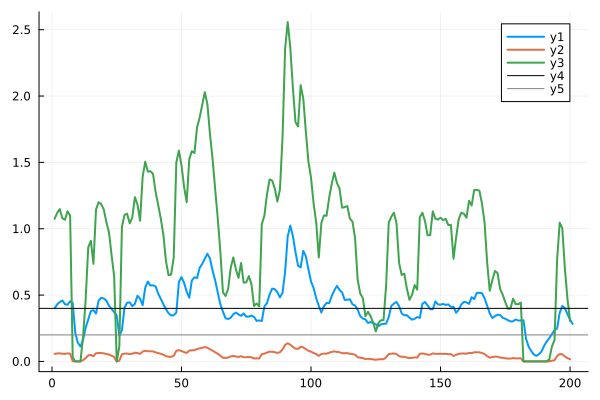

In [4]:
using Plots
X2, X2mc = init_ranom_variables(p;Nquad = 30)
states, m, f, h, y = simulate_trajectory(p,X2,200)
Plots.plot(exp.(states[1,:]), width = 2)
Plots.plot!(h, width = 2)
Plots.plot!(y, width = 2)
Plots.hline!([p.b_target], color = "black")
Plots.hline!([p.b_limit], color = "grey")

## Check state grid

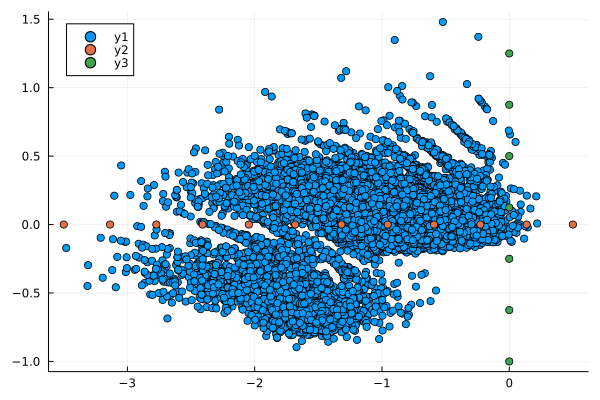

In [49]:
states, m, f, h, y = simulate_trajectory(p,X2,50000)
Plots.scatter(states[1,:], states[2,:])
bmax = 0.5; bmin = -3.5; Nb_grid = 12
b_grid = bmin:((bmax-bmin)/(Nb_grid-1)):bmax
Δbmax = 1.25; Δbmin = -1.0; NΔb_grid = 7
Δb_grid = Δbmin:((Δbmax-Δbmin)/(NΔb_grid-1)):Δbmax
Plots.scatter!(b_grid,[0.0])
Plots.scatter!(zeros(length(Δb_grid)),Δb_grid)

## Define remaining state grids

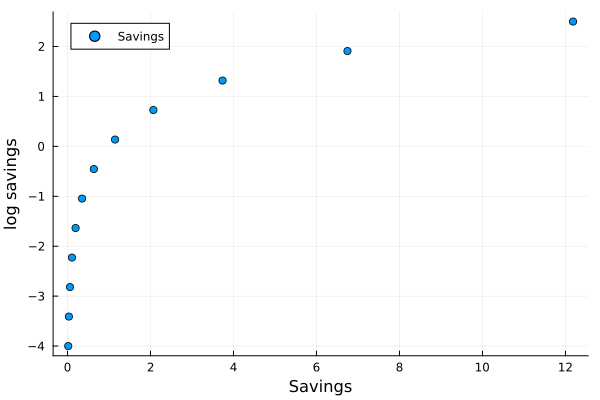

In [50]:
smax = 2.5; smin = -4.0; Ns_grid = 12
s_grid = smin:((smax-smin)/(Ns_grid-1)):smax
Plots.scatter(exp.(s_grid),s_grid, label = "Savings", xlabel = "Savings", ylabel = "log savings")

In [51]:
state_grid = [s_grid,b_grid,Δb_grid]
nothing

## Define aciton grid 

In [63]:
κmin = 0.01; κmax = 0.99; Nκ = 30
κ_grid = κmin:((κmax-κmin)/(Nκ-1)):κmax
ηmin = 0.0; ηmax=0.2; Nη = 20
η_grid = ηmin:((ηmax-ηmin)/(Nη-1)):ηmax
action_grid = [κ_grid,η_grid]
κ_grid

0.01:0.03379310344827586:0.99

# Define index and strike

# 

In [53]:
function strike(s,p)
    return 0.5*(p.b_target +p.b_limit) 
end

function index(s,X)
    return exp(s[1])+X[1]
end 

index (generic function with 1 method)

## Set up model 

In [54]:
δ = 0.95
prob, El = init(action_grid,state_grid,δ,p,X,index,strike)
estimate_time(prob)

The wieght in the random variable do not add to one, there might be an issue with your integration method.

("Estimate (sec)" => 130.98, "One call" => 8.593082427978516e-6, "Number of computations" => 2540400, "actions" => "varaible", "states" => 2032, "random variable samples" => 15, "Estimated iterations" => 60, "Number of threads" => 10)

In [55]:
#load_solution(prob,"../results/no_RA_intermidiate/sol.jld2")
solve!(prob)
nothing

Progress: 100%|█████████████████████████████████████████| Time: 0:04:28


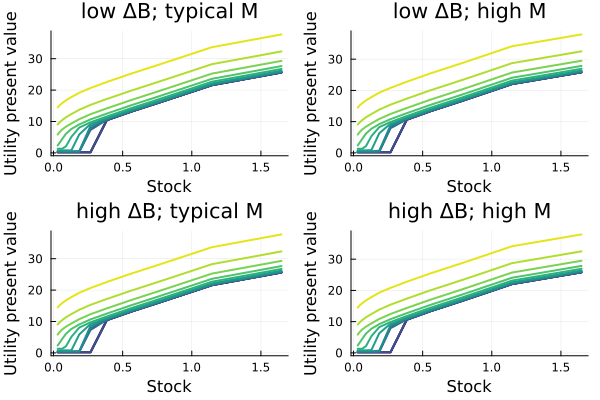

In [59]:
include("../src/plotting.jl")
plot_value_function(prob)

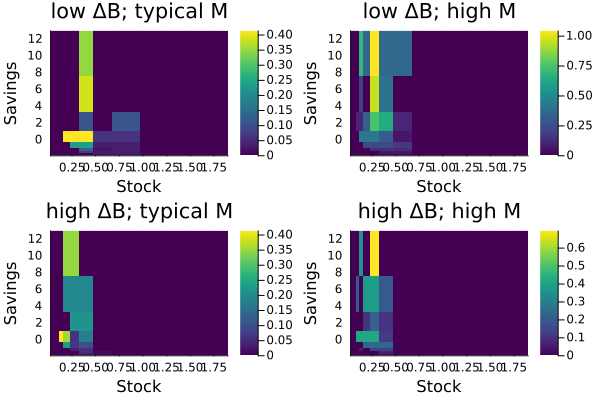

In [60]:
include("../src/plotting.jl")
plot_premiums(prob)

Seed: 72
Check premiums and claims: 0.1098? = ? 0.1741


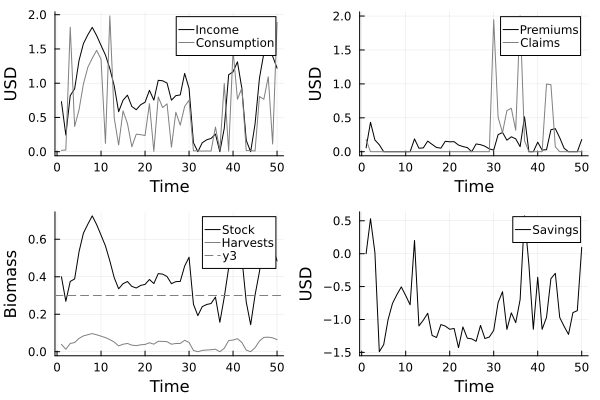

In [103]:
include("../src/plotting.jl")
using Random
seed = rand(1:1000)
Random.seed!(seed); println("Seed: ", seed)
plt,sim=plot_simulation(prob,El,Xmc,50;with_policy = false,s0 = [1.0, log(2.0),log(0.4), 0.0, 2.0])
plt

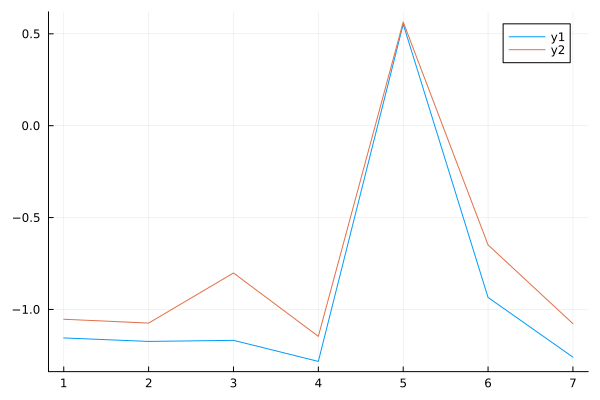

In [ ]:
Plots.plot(sim.st[40:46])
Plots.plot!(sim.κt[40:46].-sim.yt[40:46])

In [ ]:
occursin("hello", "hello world")

true